In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

ROOT = os.path.abspath("..")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
from src.utils.preprocessing import wrangle_data
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from src.models.shap_interpretation import explain_model, sample_for_shap
from sklearn.ensemble import RandomForestClassifier
from src.models.evaluate import evaluate, find_best_threshold
from sklearn.metrics import confusion_matrix
import shap
shap.initjs()

In [51]:
# wrangle data
df = wrangle_data(False)

In [52]:
# prepare features and target
X = df.drop(columns=["IS_FRAUD"])
y = df["IS_FRAUD"]

In [53]:
#split data into train, validation and test using temporal split
cutoff = int(len(X) * 0.8)
X_train_full, y_train_full = X.iloc[: cutoff], y.iloc[:cutoff]
X_test, y_test =  X.iloc[cutoff: ], y.iloc[cutoff:]

cutoff_train_val = int(len(X_train_full) * 0.8)
X_train, y_train = X_train_full.iloc[:cutoff_train_val], y_train_full.iloc[:cutoff_train_val]
X_validation, y_validation = X_train_full.iloc[cutoff_train_val:], y_train_full.iloc[cutoff_train_val:]


In [54]:
#X = 1048575
print("X length " + str(len(X)))
print("X_train length " +str(len(X_train)) + ", y_train length " +str(len(y_train)))
print("X_val length " +str(len(X_validation)) + ", y_val length " +str(len(y_validation)))
print("X_test length " +str(len(X_test))  + ", y_test length " +str(len(y_test)))

X length 1048575
X_train length 671088, y_train length 671088
X_val length 167772, y_val length 167772
X_test length 209715, y_test length 209715


In [55]:
random_forest_standard_pipeline = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ])
random_forest_standard_pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](9,)","['SENDER_ACCOUNT_ID','RECEIVER_ACCOUNT_ID','TX_AMOUNT',..., 'SENDER_STEP_COUNT','RECEIVER_STEP_COUNT','SENDER_RECEIVER_PAIR_COUNT']"
n_features_in_,int,9
,random_state,42
,sampling_strategy,'auto'
,k_neighbors,5


## Choose a classification threshold

`.predict()` uses sklearn's fixed 0.5 cutoff, which isn't necessarily the best
split point for an imbalanced fraud target. Instead, sweep thresholds against
the **validation** set (never the test set, to avoid tuning on the data we
report metrics on) and pick the one that maximizes F1 (or F-beta with beta>1
if recall should be weighted higher, since missing fraud is usually costlier
than a false alarm). This threshold is then applied as a fixed constant
everywhere below - SHAP probability comparisons, false positive/negative
lookups, and FPR/FNR.

In [56]:
val_probs = random_forest_standard_pipeline.predict_proba(X_validation)[:, 1]
random_forest_best_threshold = 0.4000 # as seen in ibm_bank_trans_03_model_training.ipynb

In [57]:
X_shap_5000, y_shap_5000 = sample_for_shap(X_test=X_test, y_test=y_test, sample_size= 5000)

In [58]:
len(X_shap_5000)

5000

In [59]:
#predict the target variable for the sub (100) of test set. So  I can compare the preidction with the SHAP values for the same 100 samples
random_forest_probs = random_forest_standard_pipeline.predict_proba(X_shap_5000)[:, 1]

In [60]:
random_forest_model = random_forest_standard_pipeline.named_steps['model']
shap_values_random_forest = explain_model(random_forest_model, X_shap=X_shap_5000)

In [61]:
shap_values_random_forest.shape

(5000, 9, 2)

In [62]:
# Get the SHAP predicted values (f(x)) for both classes
# The .values attribute contains the SHAP values, but the .base_values 
# and feature sums give us the final calculated prediction f(x)
shap_f_x_class0 = shap_values_random_forest.base_values[:, 0] + np.sum(shap_values_random_forest.values[:, :, 0], axis=1)
shap_f_x_class1 = shap_values_random_forest.base_values[:, 1] + np.sum(shap_values_random_forest.values[:, :, 1], axis=1)

In [89]:
#model prection for 0  and 1 for each row and shap value for the the two classes for each row
comparison_df = pd.DataFrame({
    'SHAP_f(x)_Class_1': (shap_f_x_class1 >= random_forest_best_threshold).astype(int),
    'Predicted_Class': (random_forest_probs >= random_forest_best_threshold).astype(int),
    'Actual_Class': y_shap_5000
}).reset_index(drop=True)

In [90]:
comparison_df.tail(10)

,SHAP_f(x)_Class_1,Predicted_Class,Actual_Class
4990,0,0,0
4991,0,0,0
4992,0,0,0
4993,0,0,0
4994,0,0,0
4995,0,0,0
4996,0,0,0
4997,0,0,0
4998,0,0,0
4999,0,0,0


In [91]:
#transactions predicted whose actual class is 1 (fraud)
Model_Prob_Class_1_df = comparison_df[comparison_df["Actual_Class"] == 1]

In [92]:
#predicted as fraud and it shap fx) values
Model_Prob_Class_1_df

,SHAP_f(x)_Class_1,Predicted_Class,Actual_Class
1896,1,1,1
2557,1,1,1
2620,1,1,1
3271,1,1,1
3472,1,1,1
3766,1,1,1
4617,1,1,1


In [93]:
# False Positive: Model predicted Class 1 (at best_threshold), but Actual Class is 0
false_positives_df = comparison_df[
    (comparison_df["Predicted_Class"] == 1) &
    (comparison_df["Actual_Class"] == 0)
]

In [94]:
false_positives_df.head(10)

,SHAP_f(x)_Class_1,Predicted_Class,Actual_Class


In [97]:
# False Negative: Model predicted Class 0 (at best_threshold), but Actual Class is 1
false_negatives_df = comparison_df[
    (comparison_df["Predicted_Class"] == 0) &
    (comparison_df["Actual_Class"] == 1)
]

In [98]:
false_negatives_df.head(10)

,SHAP_f(x)_Class_1,Predicted_Class,Actual_Class


In [99]:
# FPR/FNR on this SHAP sample, at the tuned threshold
cm = confusion_matrix(comparison_df["Actual_Class"], comparison_df["Predicted_Class"])
tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

print(f"Threshold used       : {random_forest_best_threshold:.4f}")
print(f"False Positive Rate  : {fpr:.4f}  ({fp} legit flagged as fraud out of {fp + tn})")
print(f"False Negative Rate  : {fnr:.4f}  ({fn} fraud missed out of {fn + tp})")

Threshold used       : 0.4000
False Positive Rate  : 0.0000  (0 legit flagged as fraud out of 4993)
False Negative Rate  : 0.0000  (0 fraud missed out of 7)


In [72]:
# Actual Class is 1
actual_fraud_df = comparison_df[comparison_df["Actual_Class"] == 1.0]

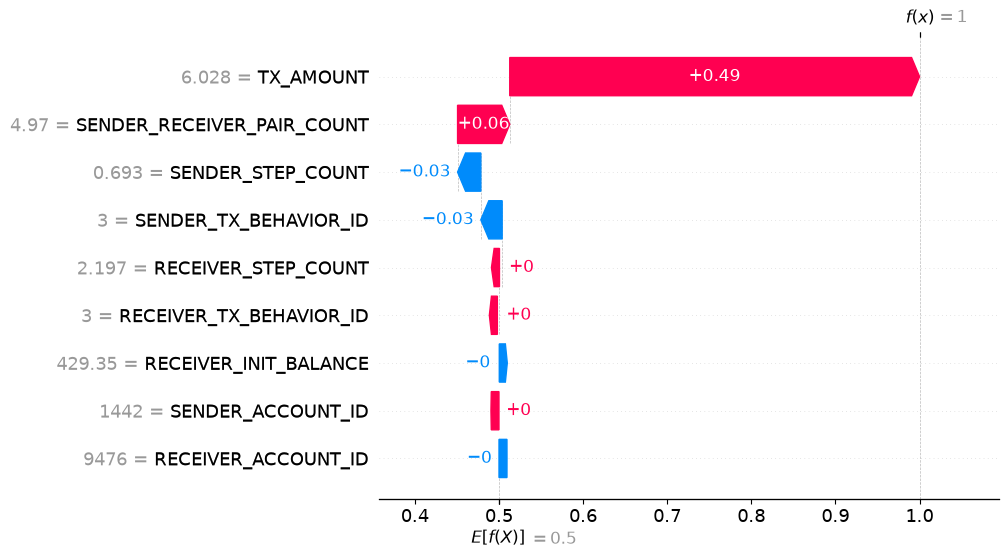

In [73]:
# shap_values_random_forest shape: (5000, 9, 2) -> (n_samples, n_features, n_classes)
# index 6 = record #7 (0-indexed) in X_shap; ":" = all 9 features; 0 = class index for legitimate
# waterfall plot shows how each feature pushed this record's legitimate-class prediction
# away from the base (expected) value
shap.plots.waterfall(shap_values_random_forest[6, :, 0])

In [74]:
actual_fraud_df.head(10)

,SHAP_f(x)_Class_1,Predicted_Class,Actual_Class
1896,0.96,1,1
2557,0.81,1,1
2620,1.00,1,1
3271,0.98,1,1
3472,0.99,1,1
3766,1.00,1,1
4617,1.00,1,1


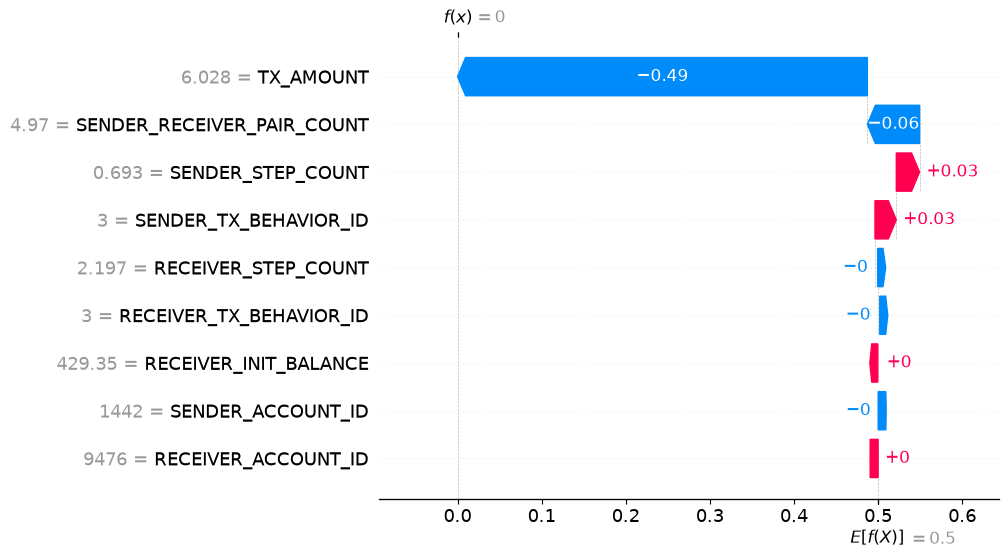

In [75]:
# examine row 7, all features, class fraud
# shap_values_random_forest shape: (5000, 9, 2) -> (n_samples, n_features, n_classes)
# index 6 = record #7 (0-indexed) in X_shap; ":" = all 9 features; 1 = class index for fraud
# waterfall plot shows how each feature pushed this record's fraud-class prediction
# away from the base (expected) value
# where prediction is legit
shap.plots.waterfall(shap_values_random_forest[6, :, 1])

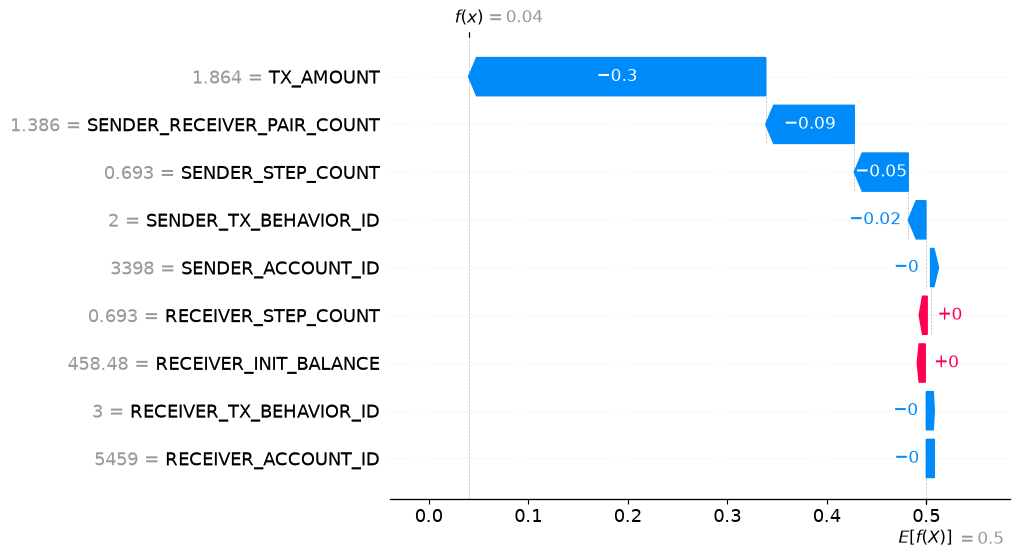

In [76]:
# shap_values_random_forest shape: (5000, 9, 2) -> (n_samples, n_features, n_classes)
# index 1896 = record #1897 (0-indexed) in X_shap; ":" = all 9 features; 0 = class index for legitimate
# waterfall plot shows how each feature pushed this record's legitimate-class prediction
# away from the base (expected) value
# where prediction is fraud
shap.plots.waterfall(shap_values_random_forest[1896, :, 0])

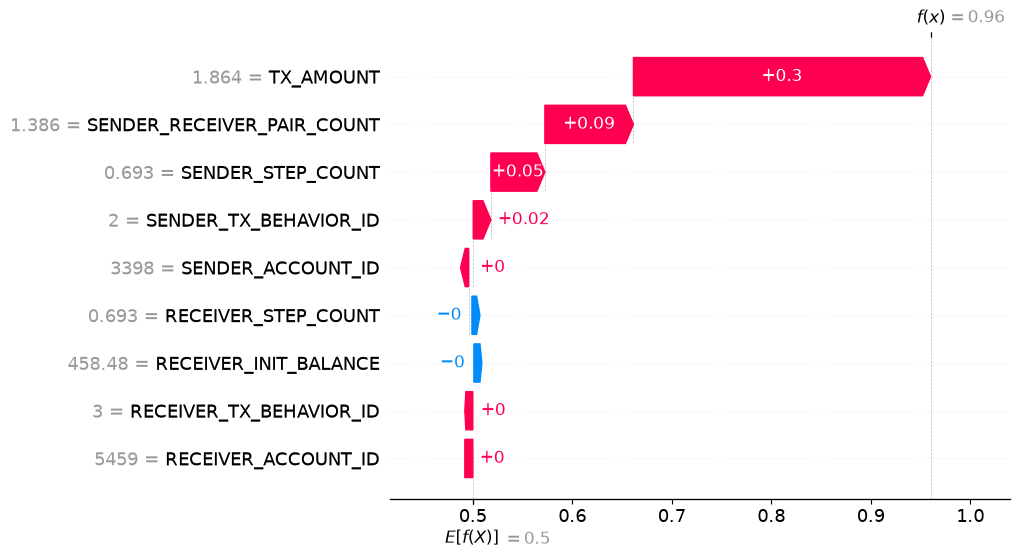

In [77]:
# examine row 1896, all features, class fraud
# shap_values_random_forest shape: (5000, 9, 2) -> (n_samples, n_features, n_classes)
# index 1896 = record #1897 (0-indexed) in X_shap; ":" = all 9 features; 1 = class index for fraud
# waterfall plot shows how each feature pushed this record's fraud-class prediction
# away from the base (expected) value
# where prediction is legit
shap.plots.waterfall(shap_values_random_forest[1896, :, 1])

In [78]:
# 2. Extract the base value, shap values, and feature values for row 0, class 1
base_value = shap_values_random_forest.base_values[0, 1]
shap_contribs = shap_values_random_forest.values[0, :, 1]
feature_inputs = shap_values_random_forest.data[0]
feature_names = shap_values_random_forest.feature_names


In [79]:
print(shap_values_random_forest.values[0, :, 1].max())

0.06119026482170286


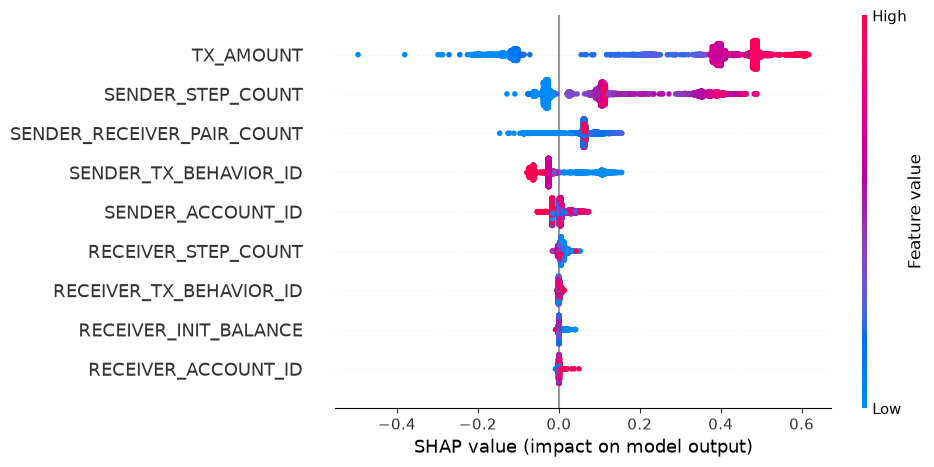

In [80]:
shap.plots.beeswarm(shap_values_random_forest[:, :, 0])

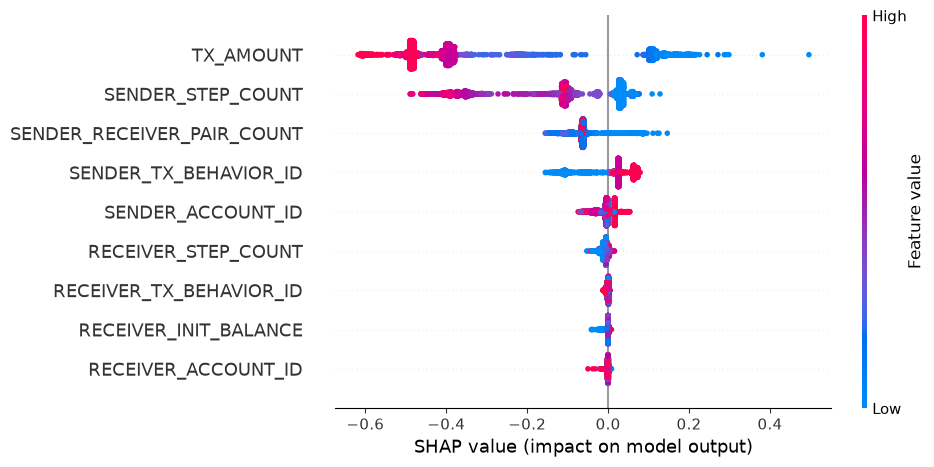

In [81]:
shap.plots.beeswarm(shap_values_random_forest[:, :, 1])

In [82]:
# Global feature importance 
import numpy as np, pandas as pd
mean_abs_shap = pd.DataFrame({
    "feature": X_shap_5000.columns,
    "mean_abs_shap": np.abs(shap_values_random_forest.values[:, :, 1]).mean(axis=0)  # class-1 (fraud) SHAP values
}).sort_values("mean_abs_shap", ascending=False)
print(mean_abs_shap.to_string(index=False))

                   feature  mean_abs_shap
                 TX_AMOUNT       0.364142
         SENDER_STEP_COUNT       0.135653
SENDER_RECEIVER_PAIR_COUNT       0.069322
     SENDER_TX_BEHAVIOR_ID       0.058916
         SENDER_ACCOUNT_ID       0.013972
       RECEIVER_STEP_COUNT       0.008460
   RECEIVER_TX_BEHAVIOR_ID       0.002090
     RECEIVER_INIT_BALANCE       0.001320
       RECEIVER_ACCOUNT_ID       0.001266


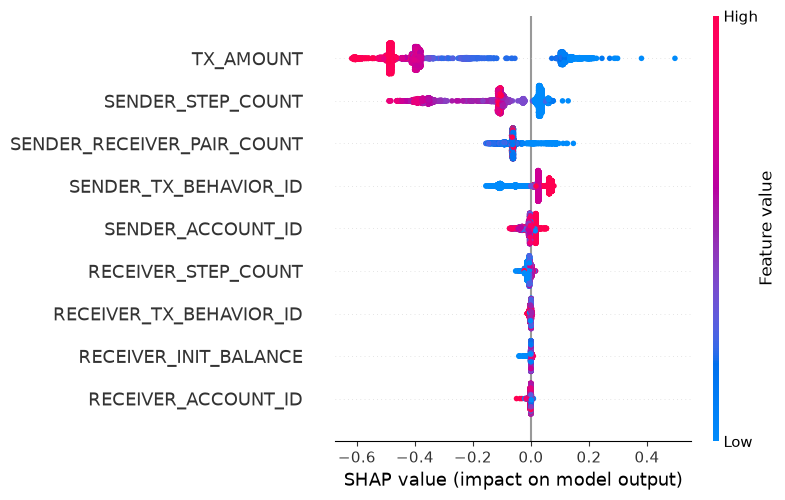

In [83]:
# summary_plot plot default is same for beeswarm plot. in this case, class 1 was observed for all shap samples and features
# new way for beeswarm plot. Not needed in this case as beeswarm plot is already generated above. 
shap.summary_plot(shap_values_random_forest[..., 1], X_shap_5000)